In [1]:
import pandas as pd

In [2]:
df_original=pd.read_csv("../data/processed/enriched_logon.csv")
df_original.head()

,user,window,logon_count,logoff_count,unique_pcs,hour,avg_logon,std_logon,avg_pcs,std_pcs,z_logon,z_pcs,night_flag,behavior_score
0,AAB0162,2010-01-04 07:00:00,1,0,1,7,0.499297,0.500351,1.0,0.0,1.000703,0.0,False,0.400281
1,AAB0162,2010-01-04 18:00:00,0,1,1,18,0.499297,0.500351,1.0,0.0,-0.997892,0.0,False,0.399157
2,AAB0162,2010-01-05 07:00:00,1,0,1,7,0.499297,0.500351,1.0,0.0,1.000703,0.0,False,0.400281
3,AAB0162,2010-01-05 18:00:00,0,1,1,18,0.499297,0.500351,1.0,0.0,-0.997892,0.0,False,0.399157
4,AAB0162,2010-01-06 07:00:00,1,0,1,7,0.499297,0.500351,1.0,0.0,1.000703,0.0,False,0.400281


In [9]:
size_of_df=df_original.shape[0]
size_of_df

3366264

In [5]:
df_test=df_original.copy()

In [6]:
df_test.head()

,user,window,logon_count,logoff_count,unique_pcs,hour,avg_logon,std_logon,avg_pcs,std_pcs,z_logon,z_pcs,night_flag,behavior_score
0,AAB0162,2010-01-04 07:00:00,1,0,1,7,0.499297,0.500351,1.0,0.0,1.000703,0.0,False,0.400281
1,AAB0162,2010-01-04 18:00:00,0,1,1,18,0.499297,0.500351,1.0,0.0,-0.997892,0.0,False,0.399157
2,AAB0162,2010-01-05 07:00:00,1,0,1,7,0.499297,0.500351,1.0,0.0,1.000703,0.0,False,0.400281
3,AAB0162,2010-01-05 18:00:00,0,1,1,18,0.499297,0.500351,1.0,0.0,-0.997892,0.0,False,0.399157
4,AAB0162,2010-01-06 07:00:00,1,0,1,7,0.499297,0.500351,1.0,0.0,1.000703,0.0,False,0.400281


In [13]:
no_of_ingested=int(size_of_df*0.005)
no_of_ingested

16831

In [27]:
#creating a column/feature named is_ingested
df_test['is_ingested']=0

In [20]:
#randomly selecting rows for anamoly ingestion
ingestion_indices=df_test.sample(no_of_ingested,random_state=42).index
ingestion_indices

Index([ 732570, 1303655, 1611614, 1552871, 3009713, 1708694, 2914105,  318282,
       1503049, 1775589,
       ...
       1168920, 3279120, 2793683, 3049175, 2031668, 2124730, 1066242, 3110744,
        658593, 2947559],
      dtype='int64', length=16831)

In [22]:
'''Types of anamolies to be ingested into the dataset
        1.login_burst
        2.device_explosion
        3.cross_shift
        4.combined
'''

'Types of anamolies to be ingested into the dataset\n        1.login_burst\n        2.device_explosion\n        3.cross_shift\n        4.combined\n'

In [26]:
split_size=no_of_ingested//4
split_size  #The no of ingestions for each type

4207

In [31]:
#Split Indices Into Four Anomaly Types
import numpy as np

indices = np.array(ingestion_indices)

login_burst_idx = indices[:split_size]
device_explosion_idx = indices[split_size:2*split_size]
cross_shift_idx = indices[2*split_size:3*split_size]
combined_idx = indices[3*split_size:]

In [35]:
#Type 1 — Login Burst
df_test.loc[login_burst_idx, "logon_count"] = np.random.randint(8, 15, size=len(login_burst_idx))
df_test.loc[login_burst_idx, "logoff_count"] = np.random.randint(0, 3, size=len(login_burst_idx))
#Type 2 — Device Explosion
df_test.loc[device_explosion_idx, "unique_pcs"] = np.random.randint(4, 7, size=len(device_explosion_idx))
#Type 3 — Cross Shift Activity
df_test.loc[cross_shift_idx, "hour"] = np.random.randint(0, 4, size=len(cross_shift_idx))
#Type 4 — Combined Anomaly
df_test.loc[combined_idx, "logon_count"] = np.random.randint(6, 10, size=len(combined_idx))
df_test.loc[combined_idx, "unique_pcs"] = np.random.randint(3, 6, size=len(combined_idx))
df_test.loc[combined_idx, "hour"] = np.random.randint(22, 24, size=len(combined_idx))
#Mark Injected Rows
df_test.loc[ingestion_indices, "is_injected"] = 1
#(Important) Track Anomaly Type
df_test["anomaly_type"] = "normal"
df_test.loc[login_burst_idx, "anomaly_type"] = "login_burst"
df_test.loc[device_explosion_idx, "anomaly_type"] = "device_explosion"
df_test.loc[cross_shift_idx, "anomaly_type"] = "cross_shift"
df_test.loc[combined_idx, "anomaly_type"] = "combined"

In [36]:
df_test["anomaly_type"].value_counts()

anomaly_type
normal              3349433
combined               4210
login_burst            4207
cross_shift            4207
device_explosion       4207
Name: count, dtype: int64

In [37]:
#recalculating the statistical values
user_stats = df_test.groupby("user").agg(
    avg_logon=("logon_count","mean"),
    std_logon=("logon_count","std"),
    avg_pcs=("unique_pcs","mean"),
    std_pcs=("unique_pcs","std")
).reset_index()

df_test = df_test.drop(columns=["avg_logon","std_logon","avg_pcs","std_pcs"], errors="ignore")

df_test = df_test.merge(user_stats,on="user",how="left")

In [40]:
#computing z_logon,z_pcs
df_test["z_logon"] = (df_test["logon_count"] - df_test["avg_logon"]) / df_test["std_logon"]
df_test["z_pcs"] = (df_test["unique_pcs"] - df_test["avg_pcs"]) / df_test["std_pcs"]

In [41]:
#Handling divide-by-zero
df_test = df_test.replace([np.inf,-np.inf],0).fillna(0)

In [43]:
"""
V3 Pipeline – Shift-Based Anomaly Detection (V4-compatible)
============================================================
Extracted from notebooks/V3.ipynb (read-only — nothing modified).
Updated for V4 synthetic anomaly validation compatibility.

Usage
-----
    result = run_v3_pipeline(df)
    metrics = evaluate_synthetic_detection(result)

`df` must have the same schema as `enriched_logon`:
    user, window, logon_count, logoff_count, unique_pcs,
    hour, avg_logon, std_logon, avg_pcs, std_pcs,
    z_logon, z_pcs, night_flag, behavior_score

V4 datasets may additionally contain:
    is_injected, anomaly_type
"""

# ── imports ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore")

# ── constants (unchanged from V3) ──────────────────────────────────
IF_FEATURES = [
    "logon_count",
    "logoff_count",
    "unique_pcs",
    "z_logon",
    "z_pcs",
]

N_CLUSTERS = 4
IF_N_ESTIMATORS = 100
IF_CONTAMINATION = "auto"
IF_RANDOM_STATE = 42
KMEANS_RANDOM_STATE = 42
PERCENTILE_THRESHOLD = 0.01

# Columns injected by the V4 synthetic experiment
_SYNTHETIC_COLS = ["is_injected", "anomaly_type"]


# ── 1. shift segmentation ──────────────────────────────────────────
def segment_shifts(df):
    """
    Segment the dataframe into Day / Evening / Night shifts.

    Shift definitions (based on the 'hour' column):
        Day     : 09 – 16
        Evening : 17 – 21
        Night   : 22 – 23  and  0 – 8
    """
    day_mask = (df["hour"] >= 9) & (df["hour"] <= 16)
    evening_mask = (df["hour"] >= 17) & (df["hour"] <= 21)
    night_mask = (df["hour"] >= 22) | (df["hour"] <= 8)

    shifts = {
        "day": df[day_mask].copy(),
        "evening": df[evening_mask].copy(),
        "night": df[night_mask].copy(),
    }
    return shifts


# ── 2. user profile aggregation ────────────────────────────────────
def build_user_profiles(df_shift):
    """
    Aggregate per-user behavioural features used for clustering.
    """
    aggregations = {
        "logon_count": ["mean", "std", "sum"],
        "unique_pcs": ["mean", "std"],
        "hour": ["mean", "std"],
    }

    user_profile = df_shift.groupby("user").agg(aggregations)

    # Flatten column names
    user_profile.columns = [
        "mean_logon_count",
        "std_logon_count",
        "total_logon_volume",
        "mean_unique_pcs",
        "std_unique_pcs",
        "mean_activity_hour",
        "activity_hour_std",
    ]

    user_profile = user_profile.reset_index()

    # Replace NaN std (single observation users)
    user_profile = user_profile.fillna(0)

    # Log transform volume to reduce skew
    user_profile["total_logon_volume"] = np.log1p(
        user_profile["total_logon_volume"]
    )

    return user_profile


# ── 3. clustering assignment ───────────────────────────────────────
def cluster_users(user_profile, n_clusters=N_CLUSTERS):
    """
    KMeans clustering on scaled user profiles.

    Returns
    -------
    user_profile : DataFrame  (with 'cluster_id' column added)
    kmeans       : fitted KMeans model
    scaler       : fitted StandardScaler
    """
    features = user_profile.drop("user", axis=1)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features)

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=KMEANS_RANDOM_STATE,
        n_init=10,
    )
    cluster_labels = kmeans.fit_predict(X_scaled)

    user_profile = user_profile.copy()
    user_profile["cluster_id"] = cluster_labels

    return user_profile, kmeans, scaler


# ── 4. merge cluster IDs back to hourly rows ───────────────────────
def merge_user_cluster_back(df_shift, user_profile):
    """
    Left-join cluster_id from user_profile onto the hourly shift dataframe.
    Safeguards against NaN cluster_id values.
    """
    df_shift = df_shift.merge(
        user_profile[["user", "cluster_id"]],
        on="user",
        how="left",
    )
    df_shift["cluster_id"] = df_shift["cluster_id"].fillna(-1).astype(int)
    return df_shift


# ── 5. per-cluster Isolation Forest training ────────────────────────
def train_cluster_specific_iforest(
    df,
    features,
    contamination=IF_CONTAMINATION,
):
    """
    Train a separate Isolation Forest inside each cluster.

    Columns added
    -------------
    cluster_if_score   : decision_function score
    cluster_if_pred    : raw prediction (1 = normal, -1 = anomaly)
    is_cluster_anomaly : binary flag (0 = normal, 1 = anomaly)

    Returns
    -------
    df : DataFrame with the three new columns
    """
    df = df.copy()
    df["cluster_if_score"] = 0.0
    df["cluster_if_pred"] = 0

    clusters = [c for c in df["cluster_id"].unique() if c != -1]

    for cluster_id in clusters:
        cluster_data = df[df["cluster_id"] == cluster_id]

        # Skip clusters that are too small
        if len(cluster_data) < 10:
            continue

        # Clean feature inputs: replace inf/-inf, fill NaN
        X = cluster_data[features].copy()
        X.replace([np.inf, -np.inf], np.nan, inplace=True)
        X.fillna(0, inplace=True)

        model = IsolationForest(
            n_estimators=IF_N_ESTIMATORS,
            contamination=contamination,
            random_state=IF_RANDOM_STATE,
        )
        model.fit(X)

        scores = model.decision_function(X)
        preds = model.predict(X)

        df.loc[cluster_data.index, "cluster_if_score"] = scores
        df.loc[cluster_data.index, "cluster_if_pred"] = preds

    # Convert to binary flag
    df["is_cluster_anomaly"] = (
        df["cluster_if_pred"].apply(lambda x: 1 if x == -1 else 0)
    )

    return df


# ── 6. percentile thresholding ──────────────────────────────────────
def apply_percentile_threshold(df, percentile=PERCENTILE_THRESHOLD):
    """
    Flag rows whose cluster_if_score falls below the 1st-percentile
    threshold **within their own cluster**.

    Adds column
    -----------
    is_anomaly_final : int (1 = anomaly, 0 = normal)
    """
    df = df.copy()
    df["is_anomaly_final"] = 0

    for cid in df["cluster_id"].unique():
        mask = df["cluster_id"] == cid
        cluster_scores = df.loc[mask, "cluster_if_score"]

        if len(cluster_scores) < 10:
            continue

        thresh = cluster_scores.quantile(percentile)
        df.loc[mask & (df["cluster_if_score"] < thresh), "is_anomaly_final"] = 1

    return df


# ── 7. process one shift end-to-end ────────────────────────────────
def _process_shift(df_shift, shift_name):
    """
    Full pipeline for a single shift segment.
    """
    # Add the shift label
    df_shift = df_shift.copy()
    df_shift["Shift"] = shift_name.capitalize()

    # 2. user profiles
    user_profile = build_user_profiles(df_shift)

    # 3. clustering
    user_profile, _kmeans, _scaler = cluster_users(user_profile)

    # 4. merge cluster_id back
    df_shift = merge_user_cluster_back(df_shift, user_profile)

    # 5. per-cluster Isolation Forest
    df_shift = train_cluster_specific_iforest(df_shift, IF_FEATURES)

    # 6. percentile thresholding
    df_shift = apply_percentile_threshold(df_shift)

    return df_shift


# ── main entry point ────────────────────────────────────────────────
def run_v3_pipeline(df):
    """
    Execute the full V3 pipeline.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain the same columns as enriched_logon.
        May optionally contain 'is_injected' and 'anomaly_type'
        (V4 synthetic experiment columns); these are preserved.

    Returns
    -------
    pd.DataFrame
        The original rows augmented with:
          - cluster_id
          - cluster_if_score
          - cluster_if_pred
          - is_cluster_anomaly
          - is_anomaly_final
    """
    # Validate that all required model features are present
    required = set(IF_FEATURES)
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required features: {missing}")

    # Detect which synthetic columns are present in the input
    present_syn_cols = [c for c in _SYNTHETIC_COLS if c in df.columns]

    # Stash synthetic columns keyed by original index so we can
    # restore them after the pipeline (which resets the index).
    if present_syn_cols:
        syn_backup = df[present_syn_cols].copy()
        syn_backup.index = df.index

    # 1. segment shifts
    shifts = segment_shifts(df)

    processed = []
    for shift_name, df_shift in shifts.items():
        result = _process_shift(df_shift, shift_name)
        processed.append(result)

    # Re-combine all shifts into one frame
    df_result = pd.concat(processed, ignore_index=False)

    # Sort by original index before restoring synthetic columns
    df_result = df_result.sort_index()

    # Restore synthetic columns if they existed
    if present_syn_cols:
        for col in present_syn_cols:
            df_result[col] = syn_backup.loc[df_result.index, col]

    # Reset index for a clean output
    df_result = df_result.reset_index(drop=True)
    return df_result


# ── V4 evaluation utility ──────────────────────────────────────────
def evaluate_synthetic_detection(df):
    """
    Evaluate how well the V3 pipeline detects synthetically-injected
    anomalies (V4 experiment).

    Parameters
    ----------
    df : pd.DataFrame
        Output of `run_v3_pipeline`.  Must contain 'is_anomaly_final'.
        Should also contain 'is_injected' and optionally 'anomaly_type'.

    Returns
    -------
    dict with keys:
        detection_rate       : fraction of injected anomalies flagged
        false_positive_rate  : fraction of normal rows incorrectly flagged
        detection_by_type    : dict {anomaly_type: detection_rate}  (if column exists)
        n_injected           : total injected anomaly rows
        n_detected           : injected anomalies that were flagged
        n_normal             : total normal (non-injected) rows
        n_false_positives    : normal rows incorrectly flagged
    """
    if "is_injected" not in df.columns:
        raise ValueError(
            "Column 'is_injected' not found. "
            "Make sure the input dataframe comes from a V4 synthetic experiment."
        )

    injected = df[df["is_injected"] == 1]
    normal = df[df["is_injected"] == 0]

    n_injected = len(injected)
    n_detected = int((injected["is_anomaly_final"] == 1).sum()) if n_injected else 0
    detection_rate = n_detected / n_injected if n_injected else 0.0

    n_normal = len(normal)
    n_fp = int((normal["is_anomaly_final"] == 1).sum()) if n_normal else 0
    fp_rate = n_fp / n_normal if n_normal else 0.0

    metrics = {
        "detection_rate": detection_rate,
        "false_positive_rate": fp_rate,
        "n_injected": n_injected,
        "n_detected": n_detected,
        "n_normal": n_normal,
        "n_false_positives": n_fp,
    }

    # Per-type breakdown
    if "anomaly_type" in df.columns and n_injected > 0:
        by_type = {}
        for atype, grp in injected.groupby("anomaly_type"):
            cnt = len(grp)
            det = int((grp["is_anomaly_final"] == 1).sum())
            by_type[atype] = det / cnt if cnt else 0.0
        metrics["detection_by_type"] = by_type

    # Per-shift breakdown
    if "Shift" in df.columns and n_injected > 0:
        metrics["detection_by_shift"] = (
            df[df["is_injected"] == 1]
            .groupby("Shift")["is_anomaly_final"]
            .mean()
            .to_dict()
        )

    return metrics




In [47]:
result=run_v3_pipeline(df_test)
metrics = evaluate_synthetic_detection(result)

In [51]:
print(metrics["detection_rate"],metrics["false_positive_rate"],metrics["detection_by_type"],metrics["detection_by_shift"])

0.01059986972227157 0.009786297571160249 {'combined': 0.009633911368015413, 'cross_shift': 0.01342123852130916, 'device_explosion': 0.010469986040018614, 'login_burst': 0.00883054892601432} {'Day': 0.01042654028436019, 'Evening': 0.011635712687402103, 'Night': 0.01007979840403192}


<h2>This is the test for raw IF predictions </h2>

In [65]:
"""
V3 Pipeline – Shift-Based Anomaly Detection (V4-compatible)
============================================================
Extracted from notebooks/V3.ipynb (read-only — nothing modified).
Updated for V4 synthetic anomaly validation compatibility.
Usage
-----
    result = run_v3_pipeline(df)
    metrics = evaluate_synthetic_detection(result)
`df` must have the same schema as `enriched_logon`:
    user, window, logon_count, logoff_count, unique_pcs,
    hour, avg_logon, std_logon, avg_pcs, std_pcs,
    z_logon, z_pcs, night_flag, behavior_score
V4 datasets may additionally contain:
    is_injected, anomaly_type
"""
# ── imports ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")
# ── constants (unchanged from V3) ──────────────────────────────────
IF_FEATURES = [
    "logon_count",
    "logoff_count",
    "unique_pcs",
    "z_logon",
    "z_pcs",
]
N_CLUSTERS = 4
IF_N_ESTIMATORS = 100
IF_CONTAMINATION = "auto"
IF_RANDOM_STATE = 42
KMEANS_RANDOM_STATE = 42
# Columns injected by the V4 synthetic experiment
_SYNTHETIC_COLS = ["is_injected", "anomaly_type"]
# ── 1. shift segmentation ──────────────────────────────────────────
def segment_shifts(df):
    """
    Segment the dataframe into Day / Evening / Night shifts.
    Shift definitions (based on the 'hour' column):
        Day     : 09 – 16
        Evening : 17 – 21
        Night   : 22 – 23  and  0 – 8
    """
    day_mask = (df["hour"] >= 9) & (df["hour"] <= 16)
    evening_mask = (df["hour"] >= 17) & (df["hour"] <= 21)
    night_mask = (df["hour"] >= 22) | (df["hour"] <= 8)
    shifts = {
        "day": df[day_mask].copy(),
        "evening": df[evening_mask].copy(),
        "night": df[night_mask].copy(),
    }
    return shifts
# ── 2. user profile aggregation ────────────────────────────────────
def build_user_profiles(df_shift):
    """
    Aggregate per-user behavioural features used for clustering.
    """
    aggregations = {
        "logon_count": ["mean", "std", "sum"],
        "unique_pcs": ["mean", "std"],
        "hour": ["mean", "std"],
    }
    user_profile = df_shift.groupby("user").agg(aggregations)
    # Flatten column names
    user_profile.columns = [
        "mean_logon_count",
        "std_logon_count",
        "total_logon_volume",
        "mean_unique_pcs",
        "std_unique_pcs",
        "mean_activity_hour",
        "activity_hour_std",
    ]
    user_profile = user_profile.reset_index()
    # Replace NaN std (single observation users)
    user_profile = user_profile.fillna(0)
    # Log transform volume to reduce skew
    user_profile["total_logon_volume"] = np.log1p(
        user_profile["total_logon_volume"]
    )
    return user_profile
# ── 3. clustering assignment ───────────────────────────────────────
def cluster_users(user_profile, n_clusters=N_CLUSTERS):
    """
    KMeans clustering on scaled user profiles.
    Returns
    -------
    user_profile : DataFrame  (with 'cluster_id' column added)
    kmeans       : fitted KMeans model
    scaler       : fitted StandardScaler
    """
    features = user_profile.drop("user", axis=1)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features)
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=KMEANS_RANDOM_STATE,
        n_init=10,
    )
    cluster_labels = kmeans.fit_predict(X_scaled)
    user_profile = user_profile.copy()
    user_profile["cluster_id"] = cluster_labels
    return user_profile, kmeans, scaler
# ── 4. merge cluster IDs back to hourly rows ───────────────────────
def merge_user_cluster_back(df_shift, user_profile):
    """
    Left-join cluster_id from user_profile onto the hourly shift dataframe.
    Safeguards against NaN cluster_id values.
    """
    df_shift = df_shift.merge(
        user_profile[["user", "cluster_id"]],
        on="user",
        how="left",
    )
    df_shift["cluster_id"] = df_shift["cluster_id"].fillna(-1).astype(int)
    return df_shift
# ── 5. per-cluster Isolation Forest training ────────────────────────
def train_cluster_specific_iforest(
    df,
    features,
    contamination=IF_CONTAMINATION,
):
    """
    Train a separate Isolation Forest inside each cluster.
    Columns added
    -------------
    cluster_if_score   : decision_function score
    cluster_if_pred    : raw prediction (1 = normal, -1 = anomaly)
    is_cluster_anomaly : binary flag (0 = normal, 1 = anomaly)
    Returns
    -------
    df : DataFrame with the three new columns
    """
    df = df.copy()
    df["cluster_if_score"] = 0.0
    df["cluster_if_pred"] = 0
    clusters = [c for c in df["cluster_id"].unique() if c != -1]
    for cluster_id in clusters:
        cluster_data = df[df["cluster_id"] == cluster_id]
        # Skip clusters that are too small
        if len(cluster_data) < 10:
            continue
        # Clean feature inputs: replace inf/-inf, fill NaN
        X = cluster_data[features].copy()
        X.replace([np.inf, -np.inf], np.nan, inplace=True)
        X.fillna(0, inplace=True)
        model = IsolationForest(
            n_estimators=IF_N_ESTIMATORS,
            contamination=contamination,
            random_state=IF_RANDOM_STATE,
        )
        model.fit(X)
        scores = model.decision_function(X)
        preds = model.predict(X)
        df.loc[cluster_data.index, "cluster_if_score"] = scores
        df.loc[cluster_data.index, "cluster_if_pred"] = preds
    # Convert to binary flag
    df["is_cluster_anomaly"] = (
        df["cluster_if_pred"].apply(lambda x: 1 if x == -1 else 0)
    )
    return df

# ── 7. process one shift end-to-end ────────────────────────────────
def _process_shift(df_shift, shift_name):
    """
    Full pipeline for a single shift segment.
    """
    # Add the shift label
    df_shift = df_shift.copy()
    df_shift["Shift"] = shift_name.capitalize()
    # 2. user profiles
    user_profile = build_user_profiles(df_shift)
    # 3. clustering
    user_profile, _kmeans, _scaler = cluster_users(user_profile)
    # 4. merge cluster_id back
    df_shift = merge_user_cluster_back(df_shift, user_profile)
    # 5. per-cluster Isolation Forest
    df_shift = train_cluster_specific_iforest(df_shift, IF_FEATURES)
    # 6. percentile thresholding
    df_shift = apply_percentile_threshold(df_shift)
    return df_shift
# ── main entry point ────────────────────────────────────────────────
def run_v3_pipeline(df):
    """
    Execute the full V3 pipeline.
    Parameters
    ----------
    df : pd.DataFrame
        Must contain the same columns as enriched_logon.
        May optionally contain 'is_injected' and 'anomaly_type'
        (V4 synthetic experiment columns); these are preserved.
    Returns
    -------
    pd.DataFrame
        The original rows augmented with:
          - cluster_id
          - cluster_if_score
          - cluster_if_pred
          - is_cluster_anomaly
          - is_cluster_anomaly
    """
    # Validate that all required model features are present
    required = set(IF_FEATURES)
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required features: {missing}")
    # Detect which synthetic columns are present in the input
    present_syn_cols = [c for c in _SYNTHETIC_COLS if c in df.columns]
    # Stash synthetic columns keyed by original index so we can
    # restore them after the pipeline (which resets the index).
    if present_syn_cols:
        syn_backup = df[present_syn_cols].copy()
        syn_backup.index = df.index
    # 1. segment shifts
    shifts = segment_shifts(df)
    processed = []
    for shift_name, df_shift in shifts.items():
        result = _process_shift(df_shift, shift_name)
        processed.append(result)
    # Re-combine all shifts into one frame
    df_result = pd.concat(processed, ignore_index=False)
    # Sort by original index before restoring synthetic columns
    df_result = df_result.sort_index()
    # Restore synthetic columns if they existed
    if present_syn_cols:
        for col in present_syn_cols:
            df_result[col] = syn_backup.loc[df_result.index, col]
    # Reset index for a clean output
    df_result = df_result.reset_index(drop=True)
    return df_result
# ── V4 evaluation utility ──────────────────────────────────────────
def evaluate_synthetic_detection(df):
    """
    Evaluate how well the V3 pipeline detects synthetically-injected
    anomalies (V4 experiment).
    Parameters
    ----------
    df : pd.DataFrame
        Output of `run_v3_pipeline`.  Must contain 'is_cluster_anomaly'.
        Should also contain 'is_injected' and optionally 'anomaly_type'.
    Returns
    -------
    dict with keys:
        detection_rate       : fraction of injected anomalies flagged
        false_positive_rate  : fraction of normal rows incorrectly flagged
        detection_by_type    : dict {anomaly_type: detection_rate}  (if column exists)
        n_injected           : total injected anomaly rows
        n_detected           : injected anomalies that were flagged
        n_normal             : total normal (non-injected) rows
        n_false_positives    : normal rows incorrectly flagged
    """
    if "is_injected" not in df.columns:
        raise ValueError(
            "Column 'is_injected' not found. "
            "Make sure the input dataframe comes from a V4 synthetic experiment."
        )
    injected = df[df["is_injected"] == 1]
    normal = df[df["is_injected"] == 0]
    n_injected = len(injected)
    n_detected = int((injected["is_cluster_anomaly"] == 1).sum()) if n_injected else 0
    detection_rate = n_detected / n_injected if n_injected else 0.0
    n_normal = len(normal)
    n_fp = int((normal["is_cluster_anomaly"] == 1).sum()) if n_normal else 0
    fp_rate = n_fp / n_normal if n_normal else 0.0
    metrics = {
        "detection_rate": detection_rate,
        "false_positive_rate": fp_rate,
        "n_injected": n_injected,
        "n_detected": n_detected,
        "n_normal": n_normal,
        "n_false_positives": n_fp,
    }
    # Per-type breakdown
    if "anomaly_type" in df.columns and n_injected > 0:
        by_type = {}
        for atype, grp in injected.groupby("anomaly_type"):
            cnt = len(grp)
            det = int((grp["is_cluster_anomaly"] == 1).sum())
            by_type[atype] = det / cnt if cnt else 0.0
        metrics["detection_by_type"] = by_type
    # Per-shift breakdown
    if "Shift" in df.columns and n_injected > 0:
        metrics["detection_by_shift"] = (
            df[df["is_injected"] == 1]
            .groupby("Shift")["is_cluster_anomaly"]
            .mean()
            .to_dict()
        )
    return metrics
# ── V4 raw IF evaluation utility ───────────────────────────────────
def evaluate_raw_if_detection(df):
    """
    Evaluate how well the **raw** Isolation Forest predictions
    (before percentile calibration) detect synthetically-injected
    anomalies.
    Uses `cluster_if_pred` (raw IF output: -1 = anomaly, 1 = normal)
    mapped to a binary flag, so results can be compared directly
    against `evaluate_synthetic_detection` (percentile-calibrated).
    Parameters
    ----------
    df : pd.DataFrame
        Output of `run_v3_pipeline`.  Must contain 'cluster_if_pred'.
        Should also contain 'is_injected' and optionally
        'anomaly_type' / 'Shift'.
    Returns
    -------
    dict  – same structure as evaluate_synthetic_detection:
        detection_rate, false_positive_rate,
        detection_by_type, detection_by_shift,
        n_injected, n_detected, n_normal, n_false_positives
    """
    if "is_injected" not in df.columns:
        raise ValueError(
            "Column 'is_injected' not found. "
            "Make sure the input dataframe comes from a V4 synthetic experiment."
        )
    # Map raw IF prediction to binary: -1 → 1 (anomaly), else → 0
    raw_flag = (df["cluster_if_pred"] == -1).astype(int)
    injected = df[df["is_injected"] == 1]
    normal = df[df["is_injected"] == 0]
    n_injected = len(injected)
    n_detected = int(raw_flag.loc[injected.index].sum()) if n_injected else 0
    detection_rate = n_detected / n_injected if n_injected else 0.0
    n_normal = len(normal)
    n_fp = int(raw_flag.loc[normal.index].sum()) if n_normal else 0
    fp_rate = n_fp / n_normal if n_normal else 0.0
    metrics = {
        "detection_rate": detection_rate,
        "false_positive_rate": fp_rate,
        "n_injected": n_injected,
        "n_detected": n_detected,
        "n_normal": n_normal,
        "n_false_positives": n_fp,
    }
    # Per-type breakdown
    if "anomaly_type" in df.columns and n_injected > 0:
        by_type = {}
        for atype, grp in injected.groupby("anomaly_type"):
            cnt = len(grp)
            det = int(raw_flag.loc[grp.index].sum())
            by_type[atype] = det / cnt if cnt else 0.0
        metrics["detection_by_type"] = by_type
    # Per-shift breakdown
    if "Shift" in df.columns and n_injected > 0:
        by_shift = {}
        for shift, grp in injected.groupby("Shift"):
            cnt = len(grp)
            det = int(raw_flag.loc[grp.index].sum())
            by_shift[shift] = det / cnt if cnt else 0.0
        metrics["detection_by_shift"] = by_shift
    return metrics


In [67]:
# ── Run pipeline & evaluate ──────────────────────────────────────
result_rawa_if = run_v3_pipeline(df_test)
metrics_raw_if     = evaluate_raw_if_detection(result)

# ── Display helper ───────────────────────────────────────────────
def display_metrics(metrics, title="Evaluation Metrics"):
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    print(f"  {'Detection Rate':<25} {metrics['detection_rate']:.4f}  ({metrics['n_detected']}/{metrics['n_injected']})")
    print(f"  {'False Positive Rate':<25} {metrics['false_positive_rate']:.6f}  ({metrics['n_false_positives']}/{metrics['n_normal']})")

    if "detection_by_type" in metrics:
        print(f"\n  Detection by Anomaly Type:")
        for atype, rate in metrics["detection_by_type"].items():
            print(f"    {atype:<30} {rate:.4f}")

    if "detection_by_shift" in metrics:
        print(f"\n  Detection by Shift:")
        for shift, rate in metrics["detection_by_shift"].items():
            print(f"    {shift:<15} {rate:.4f}")

    print(f"{'='*60}\n")

# ── Show both side by side ───────────────────────────────────────
display_metrics(metrics_raw_if,     "Raw Isolation Forest Detection")



  Raw Isolation Forest Detection
  Detection Rate            0.1543  (2606/16887)
  False Positive Rate       0.152078  (509365/3349377)

  Detection by Anomaly Type:
    combined                       0.1546
    cross_shift                    0.1498
    device_explosion               0.1531
    login_burst                    0.1599

  Detection by Shift:
    Day             0.1761
    Evening         0.1416
    Night           0.1462



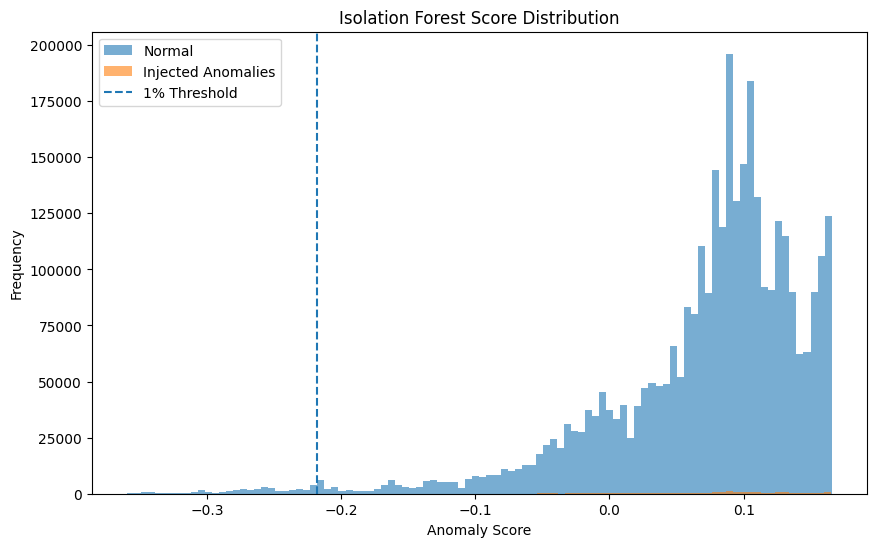

In [69]:
#visualizing the learning of the model
import matplotlib.pyplot as plt

# Separate scores
normal_scores = result_rawa_if[result_rawa_if["is_injected"] == 0]["cluster_if_score"]
anomaly_scores = result_rawa_if[result_rawa_if["is_injected"] == 1]["cluster_if_score"]

plt.figure(figsize=(10,6))

plt.hist(normal_scores, bins=100, alpha=0.6, label="Normal")
plt.hist(anomaly_scores, bins=100, alpha=0.6, label="Injected Anomalies")

plt.axvline(normal_scores.quantile(0.01), linestyle="--", label="1% Threshold")

plt.title("Isolation Forest Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [70]:
#computing ROC-AUC 
from sklearn.metrics import roc_auc_score

y_true = result["is_injected"]
scores = -result["cluster_if_score"]  # invert because lower score = anomaly

auc = roc_auc_score(y_true, scores)

print("ROC-AUC:", round(auc, 4))

ROC-AUC: 0.4996


In [72]:
scores = -result["cluster_if_score"]

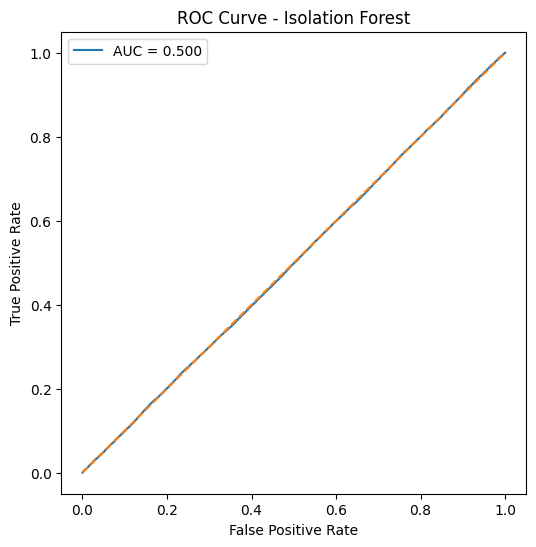

In [73]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_true, scores)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Isolation Forest")
plt.legend()
plt.show()